In [106]:
# === SETUP INICIAL ===
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caminhos do projeto
PROJ = Path.cwd().resolve().parent
DATA_DIR = PROJ / "data" / "interim"

# Nome do arquivo que você gerou (ajuste conforme seu caso)
csv_file = DATA_DIR / "singapore_grand_prix_2022-2024_all_laps.csv"

# Carrega o dataset
df = pd.read_csv(csv_file)
df = df[df["IsInOrOutLap"] == 0]

if "LapTimeSec" in df.columns:
    median_lap = df["LapTimeSec"].median(skipna=True)        # calcula mediana ignorando NaN
    limit = 1.2 * median_lap                                # define 120% da mediana como limite
    before = len(df)
    df = df[df["LapTimeSec"] <= limit]                       # mantém apenas voltas até 120% da mediana
    after = len(df)
    print(f"Filtradas {before - after} voltas acima de 120% da mediana ({median_lap:.2f}s).")

if "Compound" in df.columns:
    before = len(df)
    df = df[df["Compound"].isin(["SOFT", "MEDIUM", "HARD"])]
    after = len(df)
    print(f"Removidas {before - after} voltas com pneus intermediários/molhados. Total restante: {after}")

# --- FILTRAR APENAS VOLTAS COM PISTA VERDE ---
if "TrackStatus" in df.columns:
    before = len(df)
    df = df[df["TrackStatus"] == 1]  # mantém só pista verde
    after = len(df)
    print(f"Removidas {before - after} voltas com bandeiras amarelas, SC ou VSC. Restantes: {after}")



# Mostra informações básicas do dataset
df.info()
df.head()


Filtradas 556 voltas acima de 120% da mediana (100.35s).
Removidas 119 voltas com pneus intermediários/molhados. Total restante: 2391
Removidas 157 voltas com bandeiras amarelas, SC ou VSC. Restantes: 2234
<class 'pandas.core.frame.DataFrame'>
Index: 2234 entries, 86 to 3209
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Time                2234 non-null   object 
 1   Driver              2234 non-null   object 
 2   DriverNumber        2234 non-null   int64  
 3   LapTime             2234 non-null   object 
 4   LapNumber           2234 non-null   float64
 5   Stint               2234 non-null   float64
 6   PitOutTime          0 non-null      object 
 7   PitInTime           0 non-null      object 
 8   Sector1Time         2214 non-null   object 
 9   Sector2Time         2234 non-null   object 
 10  Sector3Time         2234 non-null   object 
 11  Sector1SessionTime  2211 non-null   object 
 12  

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Sector3TimeSec,Year,EventName,Session,AirTemp,TrackTemp,Humidity,Pressure,WindSpeed,WindDirection
86,0 days 03:37:40.852000,BOT,77,0 days 00:01:57.085000,41.0,2.0,NaN,NaN,0 days 00:00:32.265000,0 days 00:00:44.042000,...,40.778,2022,Singapore Grand Prix,Race,27.0,29.2,88.0,1009.0,0.5,0
87,0 days 03:39:35.088000,BOT,77,0 days 00:01:54.236000,42.0,2.0,NaN,NaN,0 days 00:00:30.533000,0 days 00:00:43.393000,...,40.310,2022,Singapore Grand Prix,Race,27.1,29.4,88.0,1009.0,0.0,0
88,0 days 03:41:29.217000,BOT,77,0 days 00:01:54.129000,43.0,2.0,NaN,NaN,0 days 00:00:30.327000,0 days 00:00:43.596000,...,40.206,2022,Singapore Grand Prix,Race,27.1,29.6,88.0,1009.0,0.6,162
89,0 days 03:43:22.940000,BOT,77,0 days 00:01:53.723000,44.0,2.0,NaN,NaN,0 days 00:00:30.251000,0 days 00:00:43.553000,...,39.919,2022,Singapore Grand Prix,Race,27.2,29.6,87.0,1009.0,0.6,142
90,0 days 03:45:17.925000,BOT,77,0 days 00:01:54.985000,45.0,2.0,NaN,NaN,0 days 00:00:30.142000,0 days 00:00:44.292000,...,40.551,2022,Singapore Grand Prix,Race,27.2,29.5,87.0,1009.0,1.5,149


In [98]:
# Lista das colunas para revisar quais features temos
df.columns.to_list()

# Contagem de linhas, valores nulos e tipos de dados
df.describe(include="all").transpose()

# Percentual de nulos por coluna
(df.isna().mean() * 100).sort_values(ascending=False)


PitOutTime            100.000000
PitInTime             100.000000
DeletedReason          98.932384
SpeedST                20.030503
SpeedI1                13.980681
Sector1SessionTime      1.118454
Sector1Time             1.016777
Sector1TimeSec          1.016777
Stint                   0.000000
LapTime                 0.000000
DriverNumber            0.000000
Sector3Time             0.000000
LapNumber               0.000000
Driver                  0.000000
Time                    0.000000
Sector3SessionTime      0.000000
Sector2SessionTime      0.000000
Sector2Time             0.000000
SpeedFL                 0.000000
Compound                0.000000
TyreLife                0.000000
FreshTyre               0.000000
SpeedI2                 0.000000
Team                    0.000000
LapStartTime            0.000000
TrackStatus             0.000000
LapStartDate            0.000000
Position                0.000000
Deleted                 0.000000
FastF1Generated         0.000000
IsPersonal

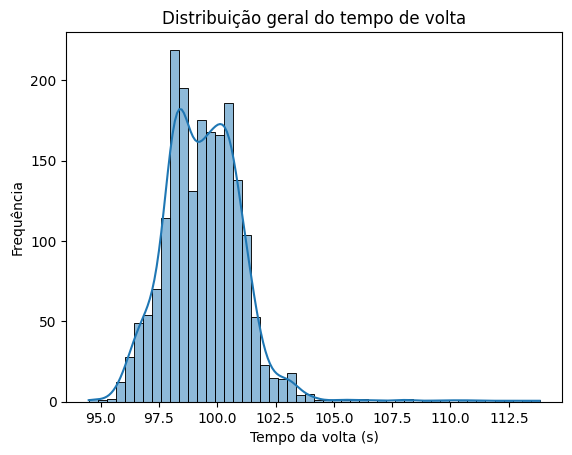

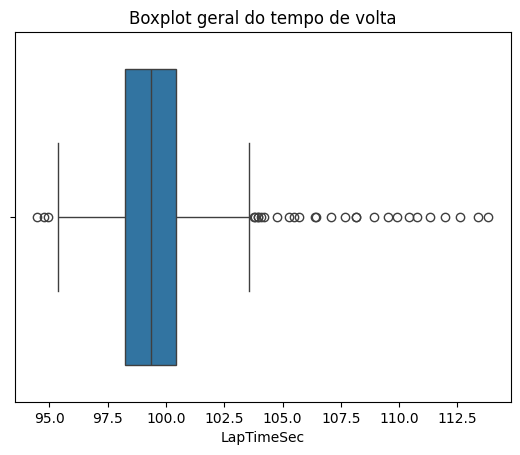

In [99]:
# Distribuição dos tempos de volta em segundos (ignora NaN)
sns.histplot(df["LapTimeSec"].dropna(), bins=50, kde=True)
plt.title("Distribuição geral do tempo de volta")
plt.xlabel("Tempo da volta (s)")
plt.ylabel("Frequência")
plt.show()

# Boxplot geral de tempos de volta
sns.boxplot(x=df["LapTimeSec"])
plt.title("Boxplot geral do tempo de volta")
plt.show()


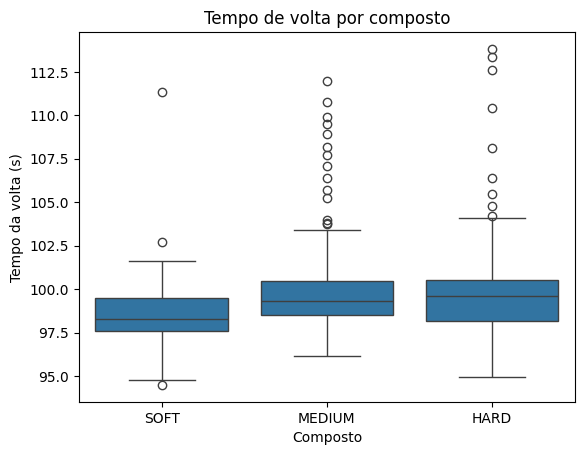

In [100]:
# Boxplot dos tempos de volta por composto
if "Compound" in df.columns:
    sns.boxplot(data=df, x="Compound", y="LapTimeSec", order=["SOFT","MEDIUM","HARD"])
    plt.title("Tempo de volta por composto")
    plt.xlabel("Composto")
    plt.ylabel("Tempo da volta (s)")
    plt.show()

# Estatísticas resumidas por composto
if "Compound" in df.columns:
    df.groupby("Compound")["LapTimeSec"].describe().round(2)


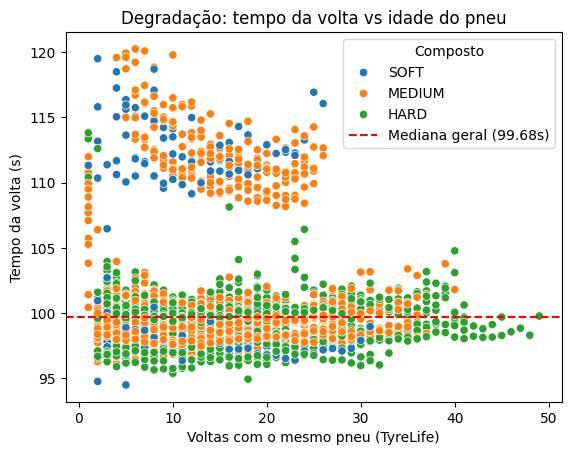

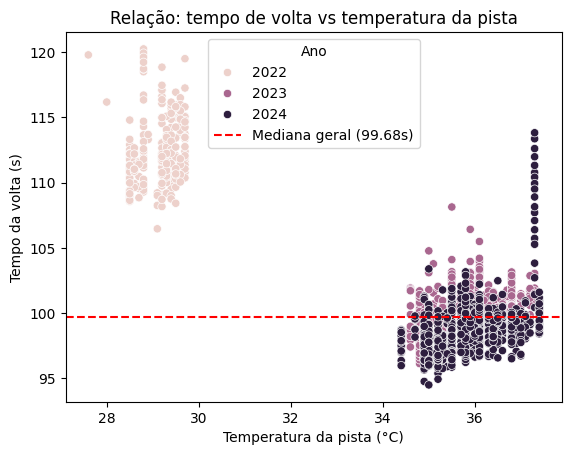

In [107]:
# Relação entre idade do pneu e tempo de volta
if "TyreLife" in df.columns:
    sns.scatterplot(data=df, x="TyreLife", y="LapTimeSec", hue="Compound")
    # Calcula a mediana geral
    mediana_lap = df["LapTimeSec"].median()
    # Adiciona linha horizontal da mediana
    plt.axhline(mediana_lap, color='red', linestyle='--', label=f'Mediana geral ({mediana_lap:.2f}s)')
    plt.title("Degradação: tempo da volta vs idade do pneu")
    plt.xlabel("Voltas com o mesmo pneu (TyreLife)")
    plt.ylabel("Tempo da volta (s)")
    plt.legend(title="Composto")
    plt.show()


if "TrackTemp" in df.columns:
    sns.scatterplot(data=df, x="TrackTemp", y="LapTimeSec", hue="Year")
    # Calcula a mediana geral
    mediana_lap = df["LapTimeSec"].median()
    # Adiciona linha horizontal da mediana
    plt.axhline(mediana_lap, color='red', linestyle='--', label=f'Mediana geral ({mediana_lap:.2f}s)')
    plt.title("Relação: tempo de volta vs temperatura da pista")
    plt.xlabel("Temperatura da pista (°C)")
    plt.ylabel("Tempo da volta (s)")
    plt.legend(title="Ano")
    plt.show()

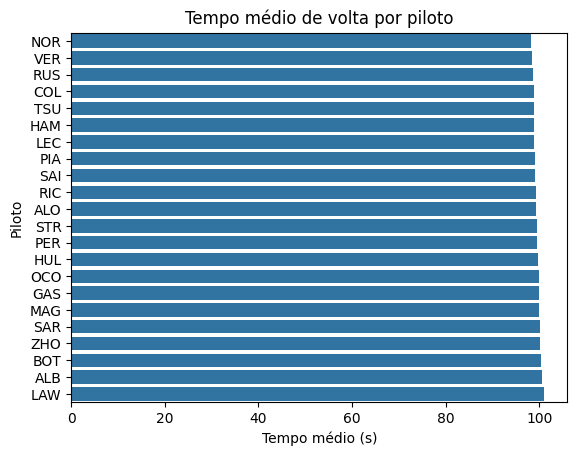

In [102]:
# Tempo médio de volta por piloto
df.groupby("Driver")["LapTimeSec"].mean().sort_values()

# Gráfico de barras com tempo médio
sns.barplot(
    y=df.groupby("Driver")["LapTimeSec"].mean().sort_values().index,
    x=df.groupby("Driver")["LapTimeSec"].mean().sort_values().values
)
plt.title("Tempo médio de volta por piloto")
plt.xlabel("Tempo médio (s)")
plt.ylabel("Piloto")
plt.show()


In [103]:
# Diferença média de tempo entre volta normal e volta pós-pit (PitOutLap)
if "IsPitOutLap" in df.columns:
    pit_out = df[df["IsPitOutLap"] == 1]["LapTimeSec"]
    clean = df[df["IsInOrOutLap"] == 0]["LapTimeSec"]

    print(f"Tempo médio de volta normal: {clean.mean():.2f}s")
    print(f"Tempo médio de volta de saída de pit: {pit_out.mean():.2f}s")


Tempo médio de volta normal: 99.44s
Tempo médio de volta de saída de pit: nans


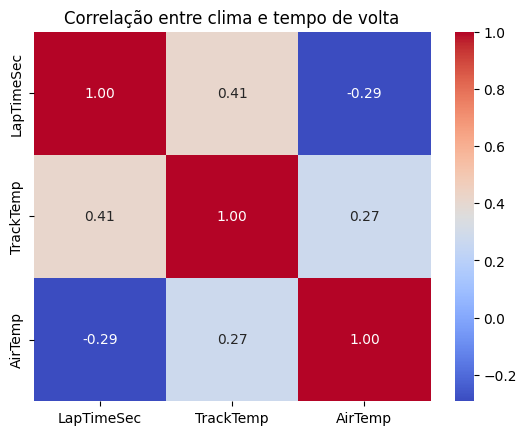

In [105]:
# Correlação entre temperatura de pista/ar e tempo de volta
if "TrackTemp" in df.columns and "LapTimeSec" in df.columns:
    corr = df[["LapTimeSec", "TrackTemp", "AirTemp"]].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Correlação entre clima e tempo de volta")
    plt.show()
